# Mini Radar Satelital: Visualización de Áreas de Interés

**Taller Semana 13.3** | Clasificación de zonas en imágenes satelitales con K-means


## Paso 0 — Instalación de librerías

In [1]:
!pip install opencv-python numpy matplotlib scikit-learn Pillow

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")
print(f"  OpenCV  : {cv2.__version__}")
print(f"  NumPy   : {np.__version__}")


✅ Librerías importadas correctamente
  OpenCV  : 4.13.0
  NumPy   : 2.0.2


## Paso 1 — Generar imagen satelital sintética

Se crea una imagen de **600×400 px** con tres zonas claramente diferenciadas:
- 🌲 **Bosque** (arriba-izquierda): tonos verdes
- 💧 **Agua** (arriba-derecha): tonos azules
- 🏙️ **Urbano** (abajo): tonos grises con estructura de grilla


In [2]:
def crear_imagen_satelital(seed=42):
    """
    Genera una imagen RGB sintética que simula una vista satelital
    con tres tipos de cobertura de suelo.
    """
    np.random.seed(seed)
    img = np.zeros((400, 600, 3), dtype=np.uint8)

    # ── Zona de bosque (arriba-izquierda) ──────────────────────────────
    bosque = np.random.normal([34, 90, 34], [12, 18, 12],
                              (180, 250, 3)).clip(0, 255).astype(np.uint8)
    for _ in range(30):
        cx = np.random.randint(10, 240)
        cy = np.random.randint(10, 170)
        r  = np.random.randint(8, 25)
        color = (
            np.random.randint(20, 60),
            np.random.randint(80, 130),
            np.random.randint(20, 60)
        )
        cv2.circle(bosque, (cx, cy), r, color, -1)
    img[0:180, 0:250] = bosque

    # ── Zona de agua (arriba-derecha) ──────────────────────────────────
    agua = np.random.normal([50, 100, 180], [10, 15, 20],
                            (180, 350, 3)).clip(0, 255).astype(np.uint8)
    for _ in range(15):
        cx = np.random.randint(10, 340)
        cy = np.random.randint(10, 170)
        r  = np.random.randint(5, 20)
        color = (
            np.random.randint(30, 80),
            np.random.randint(80, 130),
            np.random.randint(160, 220)
        )
        cv2.circle(agua, (cx, cy), r, color, -1)
    img[0:180, 250:600] = agua

    # ── Zona urbana (abajo) ────────────────────────────────────────────
    urbano = np.random.normal([160, 155, 150], [25, 22, 20],
                              (220, 600, 3)).clip(0, 255).astype(np.uint8)
    # Grilla de calles
    for i in range(0, 220, 35):
        urbano[i:i+4, :] = [200, 195, 190]
    for j in range(0, 600, 55):
        urbano[:, j:j+4] = [200, 195, 190]
    # Bloques de edificios
    for _ in range(60):
        cx = np.random.randint(10, 590)
        cy = np.random.randint(10, 210)
        w  = np.random.randint(12, 35)
        h  = np.random.randint(12, 28)
        color = (
            np.random.randint(130, 200),
            np.random.randint(125, 195),
            np.random.randint(120, 190)
        )
        cv2.rectangle(urbano, (cx, cy), (cx + w, cy + h), color, -1)
    img[180:400, 0:600] = urbano

    # Suavizado leve para simular ruido real de sensor
    img = cv2.GaussianBlur(img, (3, 3), 0)
    return img

# Crear y guardar la imagen
image_rgb = crear_imagen_satelital(seed=42)
cv2.imwrite('imagen_satelital.jpg',
            cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR))

print(f"✅ Imagen creada — dimensiones: {image_rgb.shape}  (alto x ancho x canales)")


✅ Imagen creada — dimensiones: (400, 600, 3)  (alto x ancho x canales)


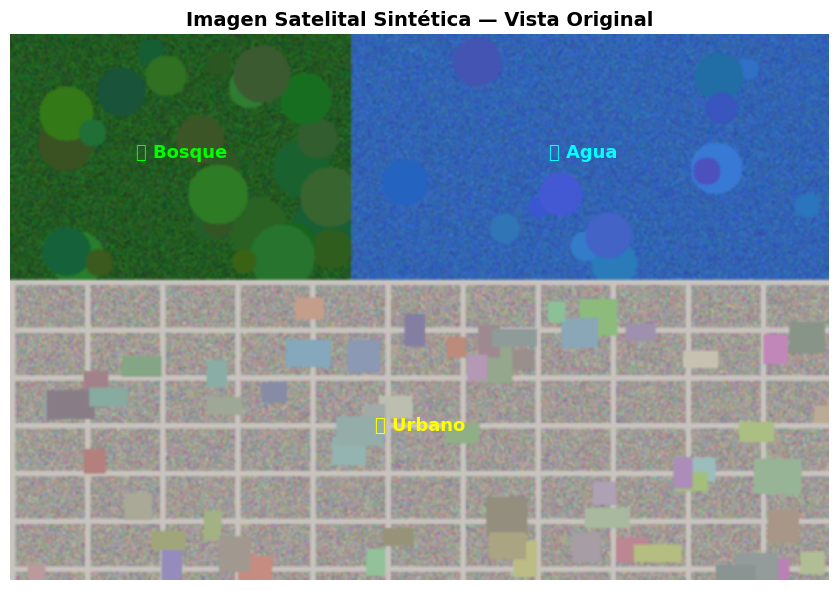

💾 Guardada: 01_imagen_original.png


In [3]:
# Visualizar la imagen satelital original
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(image_rgb)
ax.set_title('Imagen Satelital Sintética — Vista Original', fontsize=14, fontweight='bold')
ax.axis('off')

# Etiquetas de referencia
ax.text(125, 90,  '🌲 Bosque', color='lime',   fontsize=13, ha='center', fontweight='bold')
ax.text(420, 90,  '💧 Agua',   color='cyan',   fontsize=13, ha='center', fontweight='bold')
ax.text(300, 290, '🏙️ Urbano', color='yellow', fontsize=13, ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('01_imagen_original.png', dpi=120, bbox_inches='tight')
plt.show()
print("💾 Guardada: 01_imagen_original.png")


## Paso 2 — Selección de la Región de Interés (ROI)

La ROI define el área que se va a analizar. Se pueden elegir tres modos:

| Modo | Descripción |
|------|-------------|
| `full` | Toda la imagen |
| `forest` | Solo zona de bosque |
| `water` | Solo zona de agua |
| `urban` | Solo zona urbana |

Cambia `roi_mode` para explorar distintas secciones.


In [4]:
# ── Definición de ROIs predefinidas ───────────────────────────────────────
ROI_PRESETS = {
    'full'   : (0,   0,   600, 400),   # (x, y, ancho, alto)
    'forest' : (0,   0,   250, 180),
    'water'  : (250, 0,   350, 180),
    'urban'  : (0,   180, 600, 220),
}

# ── Selecciona el modo aquí ────────────────────────────────────────────────
roi_mode = 'full'   # opciones: 'full' | 'forest' | 'water' | 'urban'

x, y, w, h = ROI_PRESETS[roi_mode]
roi = image_rgb[y : y + h, x : x + w]

print(f"ROI seleccionada: '{roi_mode}'")
print(f"  Esquina superior-izquierda : ({x}, {y})")
print(f"  Dimensiones                : {w} × {h} px")
print(f"  Píxeles totales a analizar : {w * h:,}")


ROI seleccionada: 'full'
  Esquina superior-izquierda : (0, 0)
  Dimensiones                : 600 × 400 px
  Píxeles totales a analizar : 240,000


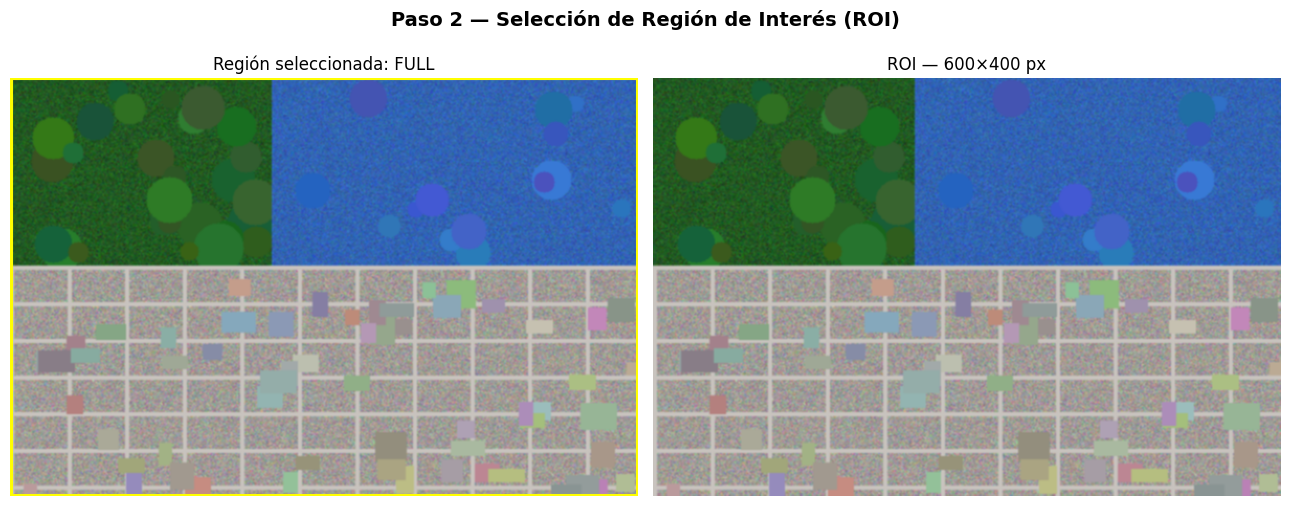

💾 Guardada: 02_roi_seleccionada.png


In [5]:
# Visualizar la imagen con la ROI marcada
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda: imagen original con recuadro de ROI
img_marcada = image_rgb.copy()
cv2.rectangle(img_marcada, (x, y), (x + w, y + h), (255, 255, 0), 3)
axes[0].imshow(img_marcada)
axes[0].set_title(f'Región seleccionada: {roi_mode.upper()}', fontsize=12)
axes[0].axis('off')

# Derecha: zoom sobre la ROI
axes[1].imshow(roi)
axes[1].set_title(f'ROI — {w}×{h} px', fontsize=12)
axes[1].axis('off')

plt.suptitle('Paso 2 — Selección de Región de Interés (ROI)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_roi_seleccionada.png', dpi=120, bbox_inches='tight')
plt.show()
print("💾 Guardada: 02_roi_seleccionada.png")


## Paso 3 — Clasificación con K-means

**K-means** agrupa los píxeles en *k* clústeres según su similitud de color en el espacio RGB.

**Parámetros clave:**
- `n_clusters`: número de clases a detectar (aquí, 3)
- `random_state`: semilla para reproducibilidad
- `n_init`: número de inicializaciones (mayor → más estable)

El algoritmo itera hasta que los centroides convergen.


In [6]:
# ── Parámetros K-means ────────────────────────────────────────────────────
N_CLUSTERS  = 3
RANDOM_SEED = 42
N_INIT      = 10

# Aplanar la ROI: de (alto, ancho, 3) → (N_pixeles, 3)
pixels = roi.reshape((-1, 3)).astype(np.float32)
print(f"Píxeles para clustering: {pixels.shape}")

# ── Entrenar K-means ──────────────────────────────────────────────────────
print(f"\nEntrenando K-means con {N_CLUSTERS} clústeres...")
kmeans = KMeans(n_clusters=N_CLUSTERS,
                random_state=RANDOM_SEED,
                n_init=N_INIT)
kmeans.fit(pixels)

# Reconstruir mapa de etiquetas con forma 2D
segmented = kmeans.labels_.reshape(roi.shape[:2])
centers   = kmeans.cluster_centers_.astype(int)

print(f"\n📊 Centroides (R, G, B) por clúster:")
for i, c in enumerate(centers):
    print(f"  Clúster {i}: R={c[0]:3d}  G={c[1]:3d}  B={c[2]:3d}")
print(f"\nIteraciones hasta convergencia: {kmeans.n_iter_}")
print(f"Inercia final               : {kmeans.inertia_:.0f}")


Píxeles para clustering: (240000, 3)

Entrenando K-means con 3 clústeres...

📊 Centroides (R, G, B) por clúster:
  Clúster 0: R= 50  G=100  B=180
  Clúster 1: R=165  G=162  B=156
  Clúster 2: R= 37  G= 94  B= 37

Iteraciones hasta convergencia: 2
Inercia final               : 136741648


## Paso 4 — Asignación automática de etiquetas

Cada clúster se etiqueta según el canal de color dominante en su centroide:
- **Verde dominante** → 🌲 Bosque
- **Azul dominante** → 💧 Agua  
- **Sin dominancia clara** → 🏙️ Urbano


In [7]:
def etiquetar_clusters(centers):
    """
    Asigna nombre ('Bosque', 'Agua', 'Urbano') a cada clúster K-means
    basándose en qué canal RGB domina en su centroide.
    Devuelve un dict  {indice_cluster: nombre}
    """
    etiquetas = {}
    for i, (r_val, g_val, b_val) in enumerate(centers):
        if b_val > r_val and b_val > g_val:
            etiquetas[i] = 'Agua'
        elif g_val > r_val and g_val > b_val:
            etiquetas[i] = 'Bosque'
        else:
            etiquetas[i] = 'Urbano'
    return etiquetas

label_map = etiquetar_clusters(centers)

# Paleta de colores para visualización
COLOR_PALETTE = {
    'Bosque': (34,  139, 34),    # verde bosque
    'Agua'  : (30,  144, 255),   # azul royal
    'Urbano': (169, 169, 169),   # gris
}

print("🏷️  Asignación de etiquetas:")
for idx, nombre in label_map.items():
    c = centers[idx]
    color = COLOR_PALETTE[nombre]
    print(f"  Clúster {idx} → {nombre:7s}  |  "
          f"Centroide RGB ({c[0]}, {c[1]}, {c[2]})  |  "
          f"Color visualización {color}")


🏷️  Asignación de etiquetas:
  Clúster 0 → Agua     |  Centroide RGB (50, 100, 180)  |  Color visualización (30, 144, 255)
  Clúster 1 → Urbano   |  Centroide RGB (165, 162, 156)  |  Color visualización (169, 169, 169)
  Clúster 2 → Bosque   |  Centroide RGB (37, 94, 37)  |  Color visualización (34, 139, 34)


## Paso 5 — Visualización de resultados

Se genera un mapa de segmentación coloreado y se superponen los contornos de cada clase sobre la ROI original.


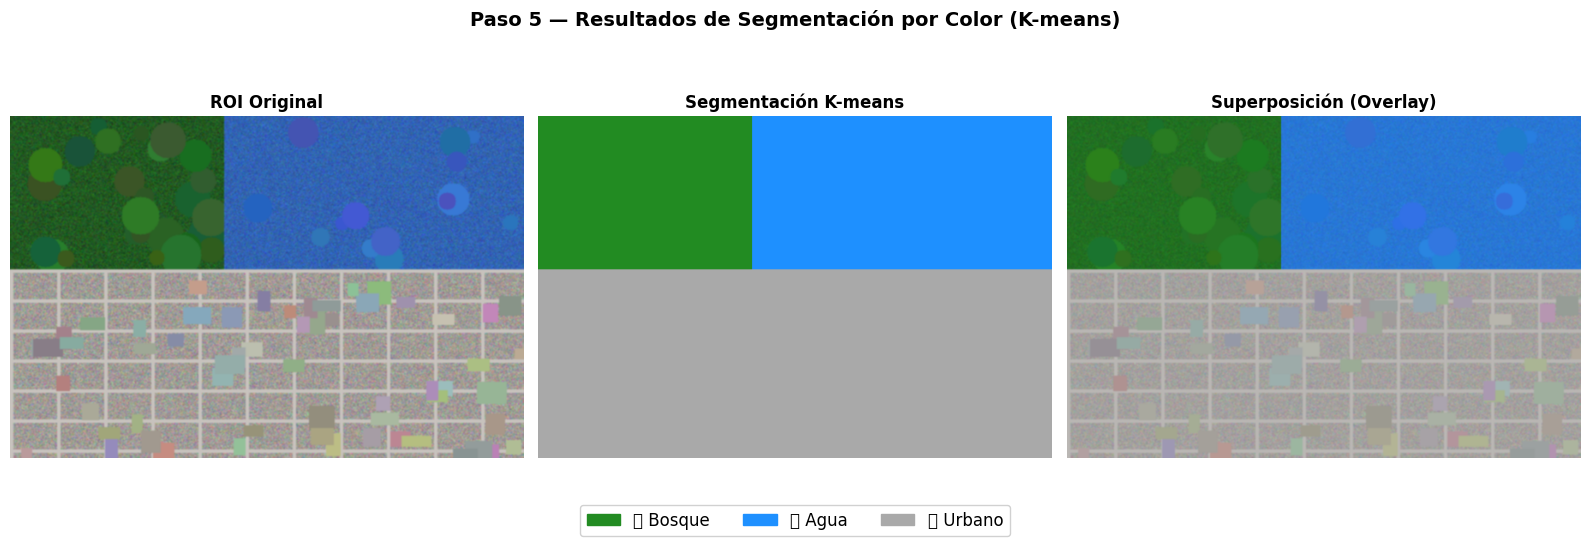

💾 Guardada: 03_segmentacion_resultado.png


In [8]:
def construir_mapa_color(segmented, label_map, color_palette):
    """
    Construye una imagen RGB donde cada píxel tiene el color
    de la clase a la que fue asignado por K-means.
    """
    h, w = segmented.shape
    mapa = np.zeros((h, w, 3), dtype=np.uint8)
    for cluster_idx, nombre in label_map.items():
        mascara = (segmented == cluster_idx)
        mapa[mascara] = color_palette[nombre]
    return mapa

mapa_color = construir_mapa_color(segmented, label_map, COLOR_PALETTE)

# ── Figura principal: 3 paneles ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1 — ROI original
axes[0].imshow(roi)
axes[0].set_title('ROI Original', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Panel 2 — Mapa de segmentación
axes[1].imshow(mapa_color)
axes[1].set_title('Segmentación K-means', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Panel 3 — Superposición (overlay)
alpha   = 0.45
overlay = (roi * (1 - alpha) + mapa_color * alpha).astype(np.uint8)
axes[2].imshow(overlay)
axes[2].set_title('Superposición (Overlay)', fontsize=12, fontweight='bold')
axes[2].axis('off')

# Leyenda compartida
leyenda = [
    mpatches.Patch(color=[c/255 for c in COLOR_PALETTE['Bosque']], label='🌲 Bosque'),
    mpatches.Patch(color=[c/255 for c in COLOR_PALETTE['Agua']],   label='💧 Agua'),
    mpatches.Patch(color=[c/255 for c in COLOR_PALETTE['Urbano']], label='🏙️ Urbano'),
]
fig.legend(handles=leyenda, loc='lower center', ncol=3, fontsize=12,
           bbox_to_anchor=(0.5, -0.05), framealpha=0.9)

plt.suptitle('Paso 5 — Resultados de Segmentación por Color (K-means)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('03_segmentacion_resultado.png', dpi=130, bbox_inches='tight')
plt.show()
print("💾 Guardada: 03_segmentacion_resultado.png")


## Paso 6 — Contornos y estadísticas por clase

Se dibuja el contorno de cada clase sobre la ROI y se calcula el porcentaje de cobertura.


In [9]:
def dibujar_contornos(roi, segmented, label_map, color_palette):
    """
    Encuentra contornos externos de cada clase y los superpone
    sobre la imagen. Devuelve la imagen anotada.
    """
    resultado = roi.copy()
    for cluster_idx, nombre in label_map.items():
        # Máscara binaria de la clase actual
        mascara = (segmented == cluster_idx).astype(np.uint8) * 255
        contornos, _ = cv2.findContours(
            mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        color_bgr = color_palette[nombre][::-1]   # RGB → BGR para OpenCV
        cv2.drawContours(resultado, contornos, -1, color_bgr, 2)
    return resultado

img_contornos = dibujar_contornos(roi, segmented, label_map, COLOR_PALETTE)

# Calcular estadísticas de cobertura
total_pixeles = segmented.size
print("📊 Cobertura por clase:")
print(f"{'Clase':<10} {'Píxeles':>10} {'Porcentaje':>12}")
print("-" * 34)
for cluster_idx, nombre in label_map.items():
    count = np.sum(segmented == cluster_idx)
    pct   = count / total_pixeles * 100
    print(f"{nombre:<10} {count:>10,} {pct:>11.1f}%")

print(f"{'TOTAL':<10} {total_pixeles:>10,} {'100.0%':>12}")


📊 Cobertura por clase:
Clase         Píxeles   Porcentaje
----------------------------------
Agua           63,000        26.2%
Urbano        132,000        55.0%
Bosque         45,000        18.8%
TOTAL         240,000       100.0%


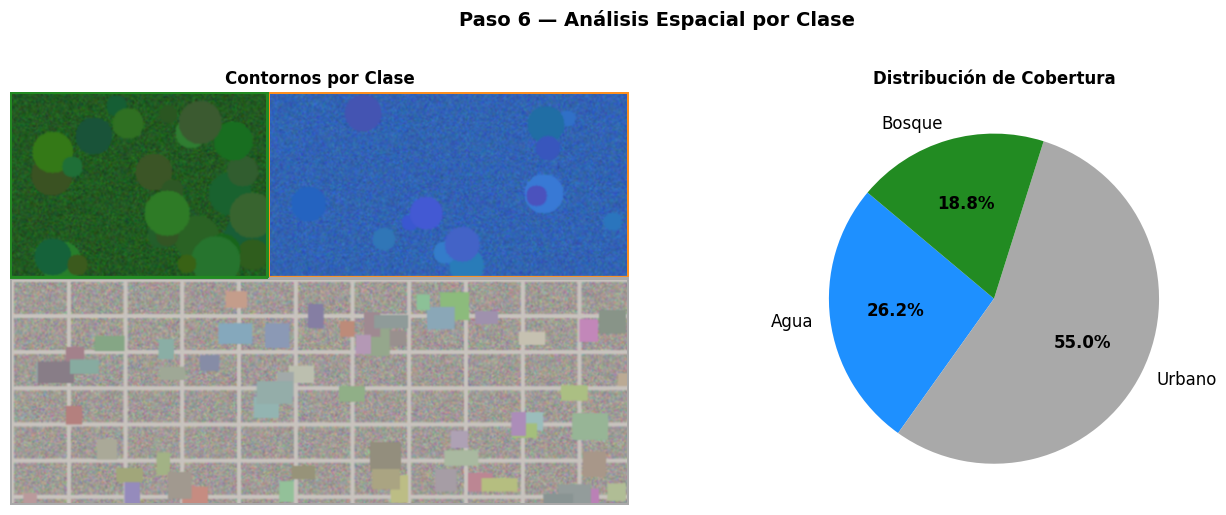

💾 Guardada: 04_contornos_estadisticas.png


In [10]:
# Visualizar imagen con contornos + gráfico de cobertura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo — ROI con contornos
axes[0].imshow(img_contornos)
axes[0].set_title('Contornos por Clase', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Panel derecho — Gráfico de torta de cobertura
nombres     = [label_map[i]   for i in range(N_CLUSTERS)]
conteos     = [np.sum(segmented == i) for i in range(N_CLUSTERS)]
colores_plt = [[c/255 for c in COLOR_PALETTE[n]] for n in nombres]

wedges, texts, autotexts = axes[1].pie(
    conteos,
    labels=nombres,
    colors=colores_plt,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')

axes[1].set_title('Distribución de Cobertura', fontsize=12, fontweight='bold')

plt.suptitle('Paso 6 — Análisis Espacial por Clase',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_contornos_estadisticas.png', dpi=130, bbox_inches='tight')
plt.show()
print("💾 Guardada: 04_contornos_estadisticas.png")


## Paso 7 — Exportar máscaras binarias por clase

Cada clase se exporta como imagen en escala de grises:
- Píxeles de la clase → **blanco (255)**
- Resto → **negro (0)**


💾 Exportando máscaras binarias:
  ✅ mascaras/agua_mascara.png            (63,000 px blancos)
  ✅ mascaras/urbano_mascara.png          (132,000 px blancos)
  ✅ mascaras/bosque_mascara.png          (45,000 px blancos)


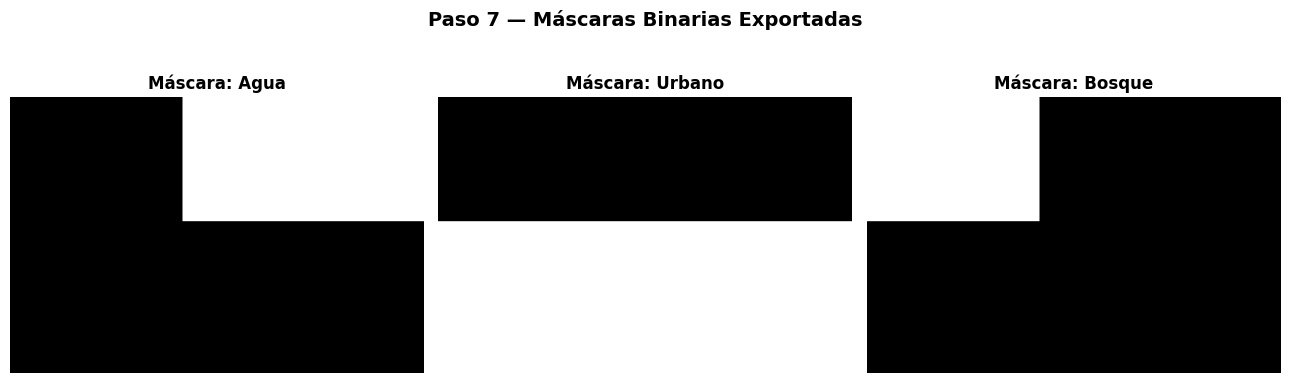

💾 Guardada: 05_mascaras_binarias.png


In [11]:
import os

os.makedirs('mascaras', exist_ok=True)

print("💾 Exportando máscaras binarias:")
for cluster_idx, nombre in label_map.items():
    mascara_bin = np.where(segmented == cluster_idx, 255, 0).astype(np.uint8)
    nombre_archivo = f"mascaras/{nombre.lower()}_mascara.png"
    cv2.imwrite(nombre_archivo, mascara_bin)
    pixeles_clase = np.sum(segmented == cluster_idx)
    print(f"  ✅ {nombre_archivo:<35}  ({pixeles_clase:,} px blancos)")

# Visualizar las tres máscaras juntas
fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(13, 4))
for ax, (cluster_idx, nombre) in zip(axes, label_map.items()):
    mascara_bin = np.where(segmented == cluster_idx, 255, 0).astype(np.uint8)
    ax.imshow(mascara_bin, cmap='gray')
    ax.set_title(f'Máscara: {nombre}', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Paso 7 — Máscaras Binarias Exportadas',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_mascaras_binarias.png', dpi=130, bbox_inches='tight')
plt.show()
print("💾 Guardada: 05_mascaras_binarias.png")


## Paso 8 — Análisis comparativo de múltiples ROIs

Se aplica el pipeline completo a las cuatro ROIs predefinidas para comparar resultados.


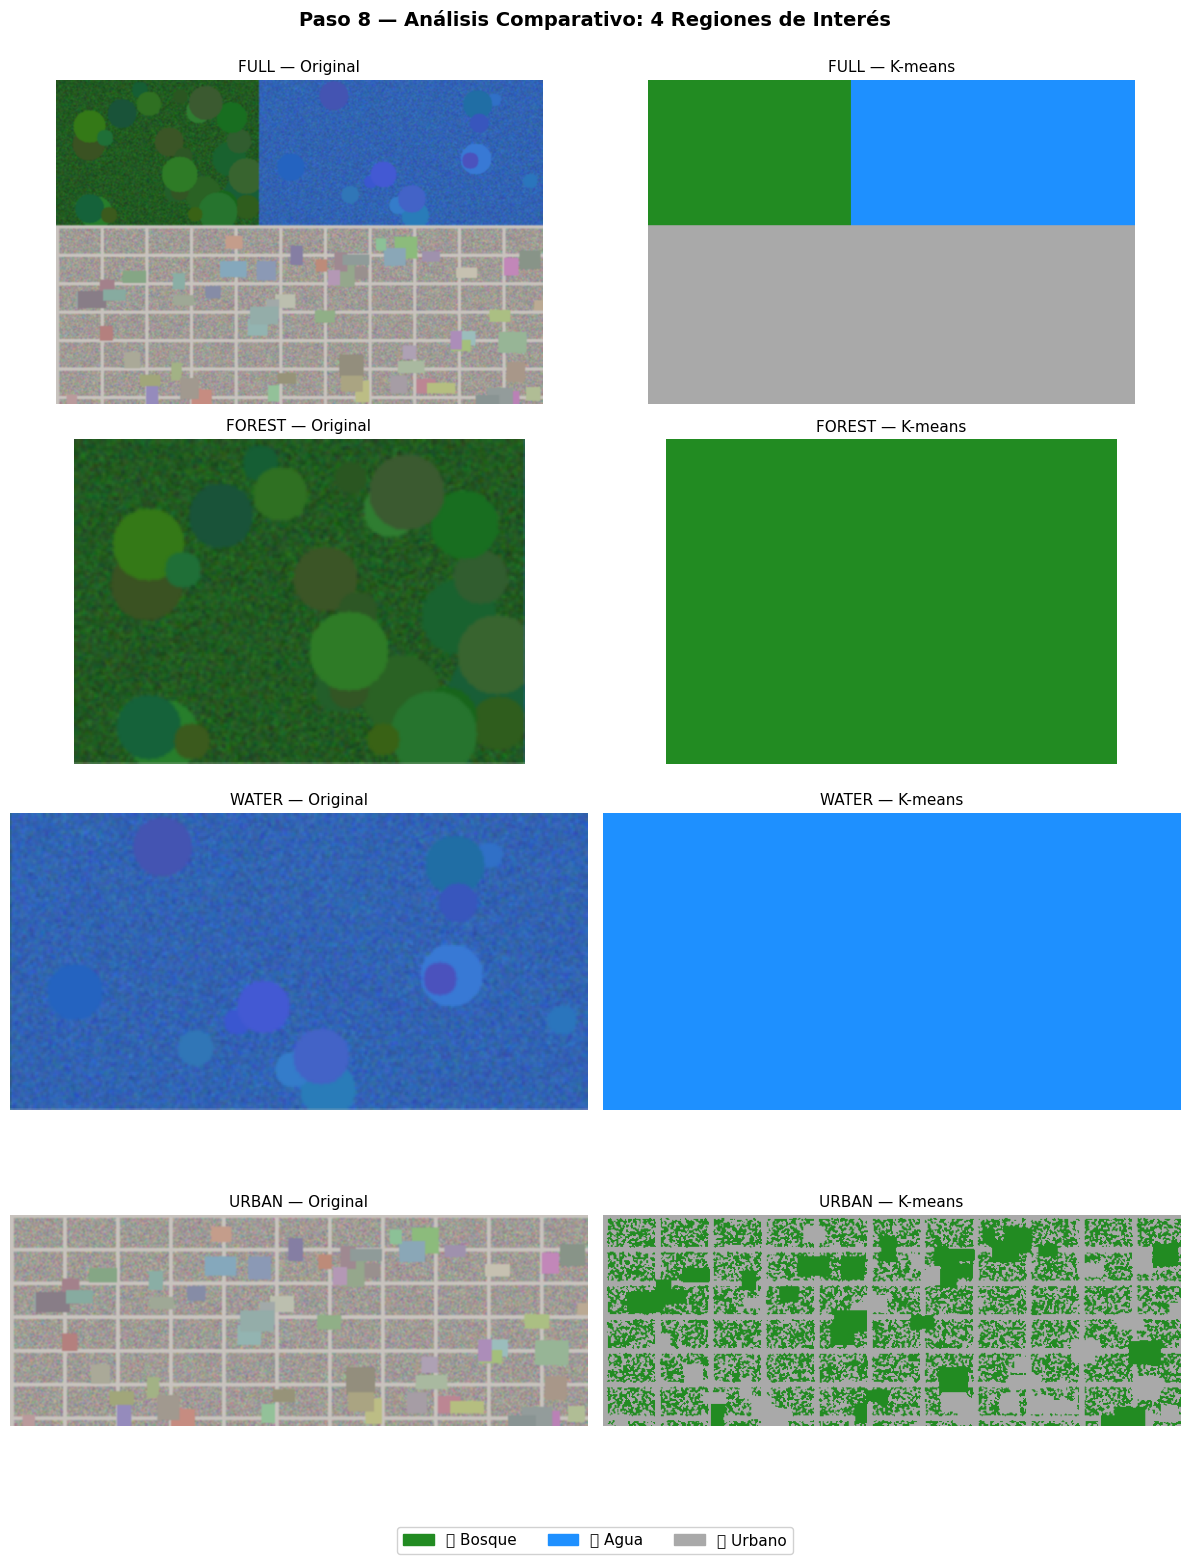

💾 Guardada: 06_analisis_multi_roi.png


In [12]:
def pipeline_completo(imagen, roi_coords, n_clusters=3, seed=42):
    """
    Aplica el pipeline completo (ROI → K-means → etiquetas → mapa)
    para una región dada.
    Devuelve: (roi, segmented, label_map, mapa_color)
    """
    x, y, w, h = roi_coords
    roi = imagen[y : y + h, x : x + w]

    pixels = roi.reshape((-1, 3)).astype(np.float32)
    km     = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    km.fit(pixels)

    segmented  = km.labels_.reshape(roi.shape[:2])
    centers    = km.cluster_centers_.astype(int)
    label_map  = etiquetar_clusters(centers)
    mapa_color = construir_mapa_color(segmented, label_map, COLOR_PALETTE)
    return roi, segmented, label_map, mapa_color

# Ejecutar pipeline para las 4 ROIs
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
resultados = {}

for row, (nombre_roi, coords) in enumerate(ROI_PRESETS.items()):
    roi, seg, lm, mapa = pipeline_completo(image_rgb, coords, N_CLUSTERS)
    resultados[nombre_roi] = (roi, seg, lm, mapa)

    # Columna izquierda: ROI original
    axes[row, 0].imshow(roi)
    axes[row, 0].set_title(f'{nombre_roi.upper()} — Original', fontsize=11)
    axes[row, 0].axis('off')

    # Columna derecha: segmentación
    axes[row, 1].imshow(mapa)
    axes[row, 1].set_title(f'{nombre_roi.upper()} — K-means', fontsize=11)
    axes[row, 1].axis('off')

# Leyenda global
fig.legend(handles=leyenda, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 0.01), framealpha=0.9)

plt.suptitle('Paso 8 — Análisis Comparativo: 4 Regiones de Interés',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.savefig('06_analisis_multi_roi.png', dpi=130, bbox_inches='tight')
plt.show()
print("💾 Guardada: 06_analisis_multi_roi.png")


## Paso 9 — Sensibilidad al número de clústeres (k)

Se compara la segmentación con k = 2, 3 y 5 para entender cómo cambia la granularidad.


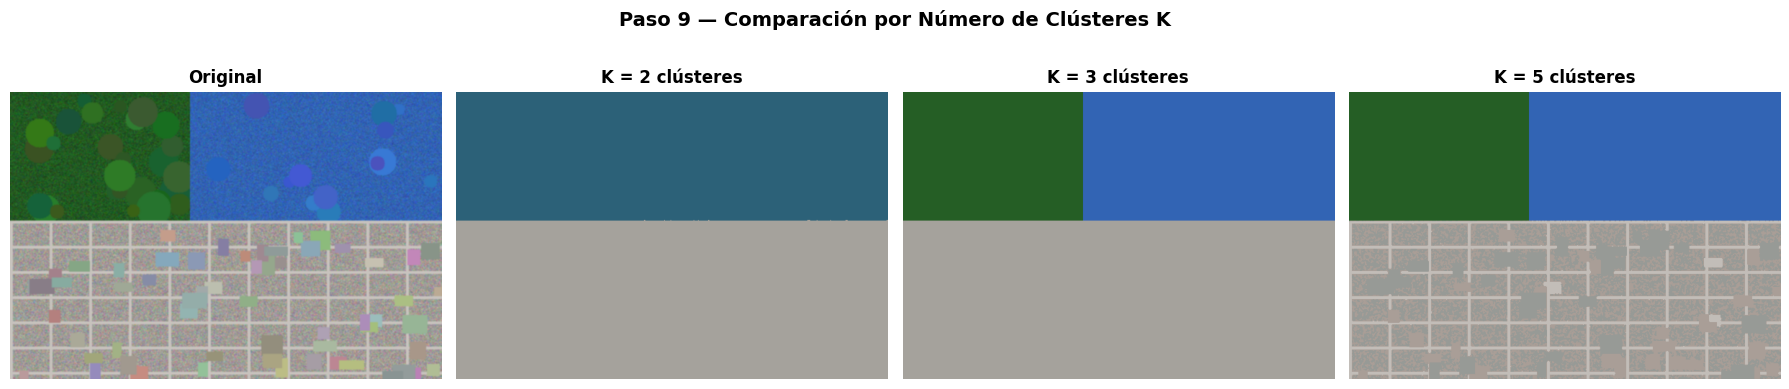

💾 Guardada: 07_comparacion_k_clusters.png


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
imagen_completa = image_rgb

# Panel 0: imagen original
axes[0].imshow(imagen_completa)
axes[0].set_title('Original', fontsize=12, fontweight='bold')
axes[0].axis('off')

for ax, k in zip(axes[1:], [2, 3, 5]):
    pixels_full = imagen_completa.reshape((-1, 3)).astype(np.float32)
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_k.fit(pixels_full)

    labels_2d = km_k.labels_.reshape(imagen_completa.shape[:2])
    centers_k = km_k.cluster_centers_.astype(int)

    # Mapa de color usando los colores promedio del centroide
    mapa_k = np.zeros_like(imagen_completa)
    for i in range(k):
        mapa_k[labels_2d == i] = centers_k[i]

    ax.imshow(mapa_k)
    ax.set_title(f'K = {k} clústeres', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Paso 9 — Comparación por Número de Clústeres K',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('07_comparacion_k_clusters.png', dpi=130, bbox_inches='tight')
plt.show()
print("💾 Guardada: 07_comparacion_k_clusters.png")
